In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/customer_data_cleaned.csv")
print("Rows loaded:", len(df))
print(df.columns.tolist())

Rows loaded: 500
['customer_id', 'signup_date', 'age', 'gender', 'city', 'segment', 'income', 'purchase_amount', 'satisfaction_score', 'age_was_missing', 'income_was_missing', 'age_band', 'signup_year', 'signup_month', 'income_band']


In [2]:
overall_trend = df[df['signup_year'].isin([2021, 2024])].groupby('signup_year')['satisfaction_score'].mean()
print("Overall satisfaction, 2021 vs 2024:")
print(overall_trend)

Overall satisfaction, 2021 vs 2024:
signup_year
2021.0    2.918699
2024.0    2.801653
Name: satisfaction_score, dtype: float64


In [3]:
segment_trend = df[df['signup_year'].isin([2021, 2024])].groupby(['segment', 'signup_year'])['satisfaction_score'].mean()
print("\nSatisfaction by segment, 2021 vs 2024:")
print(segment_trend)


Satisfaction by segment, 2021 vs 2024:
segment    signup_year
Corporate  2021.0         3.026316
           2024.0         2.517241
Retail     2021.0         2.824561
           2024.0         2.839286
SME        2021.0         2.964286
           2024.0         2.972222
Name: satisfaction_score, dtype: float64


In [4]:
segment_counts = df[df['signup_year'].isin([2021, 2024])].groupby(['segment', 'signup_year'])['customer_id'].count()
print(segment_counts)

segment    signup_year
Corporate  2021.0         38
           2024.0         29
Retail     2021.0         57
           2024.0         56
SME        2021.0         28
           2024.0         36
Name: customer_id, dtype: int64


In [5]:
# Overall change
overall_change = overall_trend[2024.0] - overall_trend[2021.0]
print("Overall change in satisfaction:", round(overall_change, 3))

# Each segment's change
corp_change = segment_trend['Corporate'][2024.0] - segment_trend['Corporate'][2021.0]
retail_change = segment_trend['Retail'][2024.0] - segment_trend['Retail'][2021.0]
sme_change = segment_trend['SME'][2024.0] - segment_trend['SME'][2021.0]

print("Corporate change:", round(corp_change, 3))
print("Retail change:", round(retail_change, 3))
print("SME change:", round(sme_change, 3))

Overall change in satisfaction: -0.117
Corporate change: -0.509
Retail change: 0.015
SME change: 0.008


In [7]:
# Check segment share of total customers, 2021 vs 2024
year_totals = df[df['signup_year'].isin([2021, 2024])].groupby('signup_year')['customer_id'].count()
segment_share = segment_counts / year_totals
print(segment_share)

segment    signup_year
Corporate  2021.0         0.308943
           2024.0         0.239669
Retail     2021.0         0.463415
           2024.0         0.462810
SME        2021.0         0.227642
           2024.0         0.297521
Name: customer_id, dtype: float64


## Comparative Insight: Satisfaction Trend, 2021 vs 2024

**Overall finding:** Average satisfaction declined slightly company-wide, from 2.92 (2021) to 2.80 (2024) — a drop of 0.117.

**Who is down:** Corporate customers, sharply — from 3.03 to 2.52 (a drop of 0.509). This is over 4x larger than the overall decline, meaning Corporate is effectively the entire cause of the company-wide dip.

**Who is up / stable:** Retail (+0.015) and SME (+0.008) — both essentially flat, neither meaningfully declining nor improving.

**Sample size check:** All segment/year groups have reasonable sample sizes (28-57 customers each), so this isn't a small-sample fluke.

**Simpson's Paradox check:** Corporate's share of the total customer base shrank from 30.9% to 23.9% over this period. Despite this — which would normally soften the impact of a declining segment on the overall average — the overall number still declined, confirming Corporate's drop is a genuine, robust signal and not a mix-shift artifact. No paradox/reversal was found.

**So what:** This is not a company-wide satisfaction problem. It's a Corporate-segment-specific issue that deserves direct investigation — e.g. did pricing, support response time, or product fit change for Corporate customers between 2021 and 2024? Retail and SME do not need the same intervention.

<Figure size 700x500 with 0 Axes>

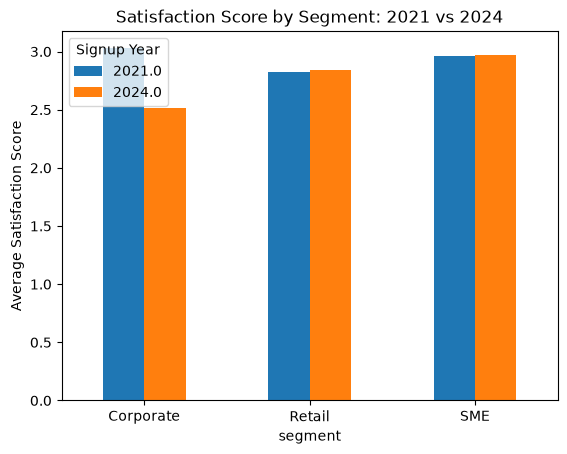

In [8]:
plt.figure(figsize=(7,5))
segment_trend.unstack().plot(kind='bar')
plt.title('Satisfaction Score by Segment: 2021 vs 2024')
plt.ylabel('Average Satisfaction Score')
plt.xticks(rotation=0)
plt.legend(title='Signup Year')
plt.show()